# Day 04  Delta P theo pathway NGS

[Open in Colab](https://colab.research.google.com/github/ketnoimaytinh797-dotcom/EGFR-Radiomics-MiniBootcamp/blob/main/book/day04.ipynb)

[Slide của buổi này](_static/slides/day04_slides.pptx)

## Mục tiêu bài học

- Ghép predicted probability với subset NGS
- Tính delta median P và delta mean P theo pathway
- Vẽ một bar chart và một boxplot
- Đọc kết quả theo hướng sinh học

## Nội dung

Buổi này không hỏi mô hình đúng hay sai nữa.  
Buổi này hỏi xác suất dự đoán thay đổi ra sao giữa nhóm có và không có đột biến pathway.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

GITHUB_USER = "ketnoimaytinh797-dotcom"
REPO_NAME = "EGFR-Radiomics-MiniBootcamp"
BRANCH = "main"

def read_csv_demo(filename):
    local_candidates = [
        Path("data") / filename,
        Path("../data") / filename,
        Path(filename),
    ]
    for path in local_candidates:
        if path.exists():
            return pd.read_csv(path)
    url = f"https://raw.githubusercontent.com/{GITHUB_USER}/{REPO_NAME}/{BRANCH}/data/{filename}"
    return pd.read_csv(url)


In [2]:
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

plt.rcParams["figure.dpi"] = 160
df = read_csv_demo("nsclc_egfr_radiomics_simplified.csv")
ngs = read_csv_demo("ngs_pathway_demo_64.csv")
output_dir = Path("outputs/day04")
output_dir.mkdir(parents=True, exist_ok=True)


## Bước 1  Tạo mô hình ring1 trên toàn cohort và lấy predicted probability


In [3]:
clinical_cols = ["age", "sex", "smoking_status", "histology", "stage", "tumor_size_mm", "tumor_volume_cm3", "tp53_mutation"]
ring1_cols = clinical_cols + [c for c in df.columns if c.startswith("ring1_")]

def make_pipe(X):
    cat = [c for c in X.columns if X[c].dtype == "object"]
    num = [c for c in X.columns if c not in cat]

    pre = ColumnTransformer([
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scale", StandardScaler())
        ]), num),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat),
    ])

    return Pipeline([
        ("pre", pre),
        ("model", LogisticRegression(max_iter=1000))
    ])

X = df[ring1_cols].copy()
y = df["egfr_mutation"].astype(int)

pipe = make_pipe(X)
pipe.fit(X, y)

df["pred_prob_ring1"] = pipe.predict_proba(X)[:, 1]
df[["patient_id", "pred_prob_ring1"]].head()


,patient_id,pred_prob_ring1
0,P001,0.697931
1,P002,0.123757
2,P003,0.685775
3,P004,0.061206
4,P005,0.469973


## Bước 2  Ghép predicted probability vào bảng NGS


In [4]:
ngs2 = ngs.merge(df[["patient_id", "pred_prob_ring1"]], on="patient_id", how="left")
ngs2.head()


,patient_id,egfr_mutation,pathway_RTK_RAS,pathway_PI3K,pathway_DNA_repair,pathway_Cell_cycle,pathway_TP53,pred_prob_ring1
0,P096,1,0,0,1,1,0,0.656121
1,P016,0,0,0,0,0,1,0.434749
2,P031,1,0,0,1,1,1,0.945204
3,P159,0,0,0,0,1,0,0.831792
4,P129,0,1,1,0,0,1,0.048468


## Bước 3  Tính delta theo từng pathway


In [5]:
rows = []
for pw in ["pathway_RTK_RAS", "pathway_PI3K", "pathway_DNA_repair", "pathway_Cell_cycle", "pathway_TP53"]:
    name = pw.replace("pathway_", "")
    mut = ngs2.loc[ngs2[pw] == 1, "pred_prob_ring1"]
    wt = ngs2.loc[ngs2[pw] == 0, "pred_prob_ring1"]
    pval = mannwhitneyu(mut, wt, alternative="two-sided").pvalue

    rows.append({
        "Pathway": name,
        "n_mut": int((ngs2[pw] == 1).sum()),
        "Median P mut": round(mut.median(), 3),
        "Median P wt": round(wt.median(), 3),
        "Delta median P": round(mut.median() - wt.median(), 3),
        "Mean P mut": round(mut.mean(), 3),
        "Mean P wt": round(wt.mean(), 3),
        "Delta mean P": round(mut.mean() - wt.mean(), 3),
        "p value": round(pval, 3),
    })

pathway_table = pd.DataFrame(rows).sort_values("Delta median P", ascending=False)
pathway_table.to_csv(output_dir / "pathway_delta_table.csv", index=False)
pathway_table


,Pathway,n_mut,Median P mut,Median P wt,Delta median P,Mean P mut,Mean P wt,Delta mean P,p value
1,PI3K,24,0.596,0.364,0.232,0.576,0.395,0.181,0.028
2,DNA_repair,19,0.489,0.404,0.085,0.536,0.432,0.104,0.370
3,Cell_cycle,24,0.498,0.418,0.080,0.470,0.459,0.011,0.851
0,RTK_RAS,22,0.442,0.434,0.008,0.467,0.461,0.006,0.961
4,TP53,28,0.386,0.435,-0.049,0.440,0.481,-0.041,0.680


### Cách đọc bảng

Nếu một pathway có delta median P dương và lớn thì xác suất dự đoán ở nhóm có pathway đó thường cao hơn.  
Trong bộ demo này PI3K đứng đầu bảng.


## Bước 4  Vẽ bar chart cho delta median P


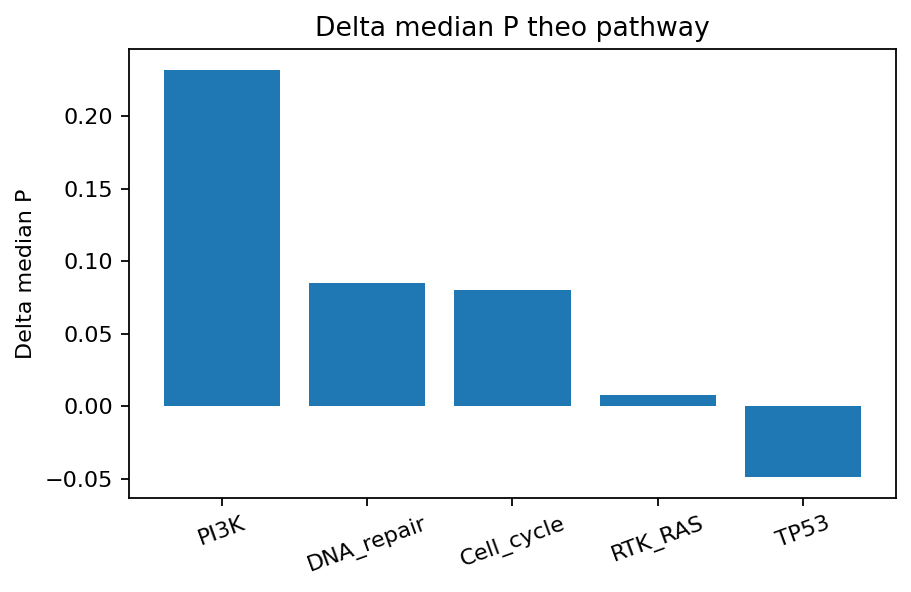

In [6]:
fig, ax = plt.subplots(figsize=(5.8, 3.8))
ax.bar(pathway_table["Pathway"], pathway_table["Delta median P"])
ax.set_title("Delta median P theo pathway")
ax.set_ylabel("Delta median P")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(output_dir / "delta_median_pathway.png")
plt.show()


## Bước 5  Vẽ boxplot cho pathway đứng đầu


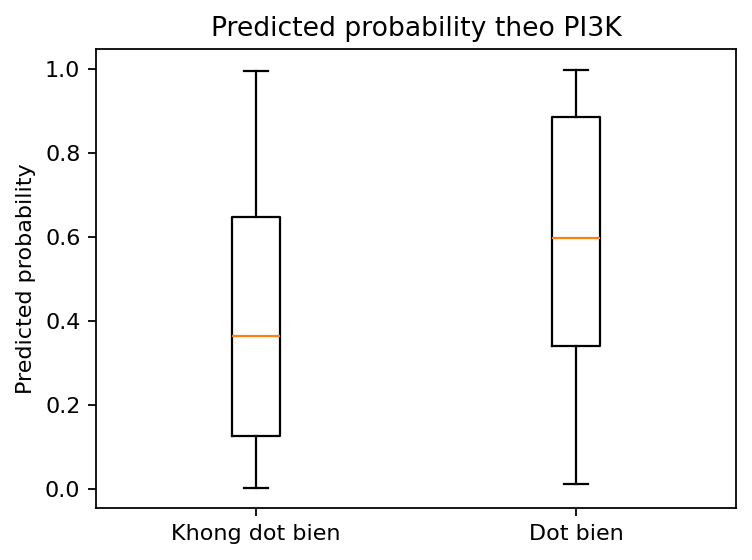

In [7]:
plot_df = ngs2.copy()
plot_df["Nhom PI3K"] = plot_df["pathway_PI3K"].map({0: "Khong dot bien", 1: "Dot bien"})

fig, ax = plt.subplots(figsize=(4.8, 3.6))
ax.boxplot(
    [plot_df.loc[plot_df["Nhom PI3K"] == "Khong dot bien", "pred_prob_ring1"],
     plot_df.loc[plot_df["Nhom PI3K"] == "Dot bien", "pred_prob_ring1"]],
    tick_labels=["Khong dot bien", "Dot bien"]
)
ax.set_title("Predicted probability theo PI3K")
ax.set_ylabel("Predicted probability")
fig.tight_layout()
fig.savefig(output_dir / "boxplot_pi3k.png")
plt.show()


## Bước 6  Viết ngắn kết quả của buổi 4


In [8]:
top_pathway = pathway_table.iloc[0]["Pathway"]
top_delta = pathway_table.iloc[0]["Delta median P"]

summary_day04 = (
    f"Trong subset NGS, pathway {top_pathway} co delta median P {top_delta:.3f}. "
    f"Dieu nay cho thay xac suat du doan ring1 tang ro hon o nhom co dot bien pathway nay trong bo demo."
)
summary_day04


'Trong subset NGS, pathway PI3K co delta median P 0.232. Dieu nay cho thay xac suat du doan ring1 tang ro hon o nhom co dot bien pathway nay trong bo demo.'

## Tự kiểm tra

- Có phân biệt được delta median P và delta mean P chưa
- Có biết vì sao subset NGS chỉ là một phân tích bổ sung chưa
- Có biết pathway nào đứng đầu ở bộ demo này chưa
- Có lưu đủ bảng và hai hình chưa
